# HP k=24 Machine Learning Classification

ML-based classification to predict same-superfamily matches using HP k=24 features.

**Goal**: Train a classifier using original + log-transformed features to discriminate
same-superfamily vs different-superfamily protein pairs.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Add notebook directory to path for imports
sys.path.insert(0, str(Path.cwd()))
from scope_kmerseek_utils import (
    read_csv_with_size_limit,
    kmerseek_to_rocx,
    plot_sensitivity_from_rocx,
    compute_auc
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Target AUC to beat (TEA baseline)
FOLDSEEK_AUC = 0.574
TEA_AUC = 0.580
TARGET_AUC = TEA_AUC

def evaluate_threshold(df, metric, threshold, greater_than=True):
    """
    Evaluate AUC (sensitivity until first FP) at a given threshold.
    Returns AUC, number of queries, and filtered dataframe.
    """
    if greater_than:
        filtered = df.filter(pl.col(metric) > threshold)
    else:
        filtered = df.filter(pl.col(metric) < threshold)
    
    if len(filtered) == 0:
        return 0.0, 0, None
    
    rocx = kmerseek_to_rocx(filtered, score_col='tfidf', overlap_threshold=0.0)
    if len(rocx) == 0:
        return 0.0, 0, None
    
    frac, sens = plot_sensitivity_from_rocx(rocx, level_col='SFAM')
    auc = compute_auc(frac, sens)
    
    return auc, len(rocx), rocx

def compute_sfam_auc_from_predictions(df, score_col='ml_score', threshold=0.5):
    """
    Compute superfamily-level AUC (sensitivity until first FP) from ML predictions.
    """
    filtered = df.filter(pl.col(score_col) > threshold)
    if len(filtered) == 0:
        return 0.0, 0
    
    rocx = kmerseek_to_rocx(filtered, score_col='tfidf', overlap_threshold=0.0)
    if len(rocx) == 0:
        return 0.0, 0
    
    frac, sens = plot_sensitivity_from_rocx(rocx, level_col='SFAM')
    auc = compute_auc(frac, sens)
    
    return auc, len(rocx)

print(f"Target: AUC > {TARGET_AUC:.3f} (TEA baseline)")


Target: AUC > 0.580 (TEA baseline)


## 1. Load Data

In [3]:
# Load HP k=24 data
data_dir = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity")
hp_k24_path = data_dir / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k24.scaled1.kmerseek.results.csv"

print("Loading HP k=24...")
hp_k24 = read_csv_with_size_limit(hp_k24_path)
print(f"HP k=24 shape: {hp_k24.shape}")
print(f"Columns: {hp_k24.columns}")

# Add log-transformed features to hp_k24
numeric_cols = [
    "containment", "n_intersecting_hashes", "jaccard", "max_containment",
    "average_abund", "median_abund", "std_abund", "containment_target_in_query",
    "f_weighted_target_in_query", "tfidf", "average_kmer_frequency",
    "prob_random_cooccurrence", "prob_random_cooccurrence_symmetric",
    "expected_intersecting_hashes", "observed_over_expected", "region_length"
]
log_transforms = [
    pl.when(pl.col(col) >= 0)
    .then((pl.col(col) + 1).log())
    .otherwise(-(-pl.col(col) + 1).log())
    .alias(f"log_{col}")
    for col in numeric_cols if col in hp_k24.columns
]
hp_k24 = hp_k24.with_columns(log_transforms)
print(f"Added {len([c for c in hp_k24.columns if c.startswith('log_')])} log features")

hp_k24.head()

Loading HP k=24...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k24.scaled1.kmerseek.results.csv (0.12 GB) - reading all rows...
HP k=24 shape: (223459, 30)
Columns: ['query_name', 'query_md5', 'target_name', 'target_md5', 'containment', 'n_intersecting_hashes', 'ksize', 'scaled', 'moltype', 'jaccard', 'max_containment', 'average_abund', 'median_abund', 'std_abund', 'containment_target_in_query', 'f_weighted_target_in_query', 'tfidf', 'average_kmer_frequency', 'prob_random_cooccurrence', 'prob_random_cooccurrence_symmetric', 'expected_intersecting_hashes', 'observed_over_expected', 'query_start', 'query_end', 'query_subseq', 'target_start', 'target_end', 'target_subseq', 'moltype_seq', 'region_length']
Added 16 log features


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,log_containment,log_n_intersecting_hashes,log_jaccard,log_max_containment,log_average_abund,log_median_abund,log_std_abund,log_containment_target_in_query,log_f_weighted_target_in_query,log_tfidf,log_average_kmer_frequency,log_prob_random_cooccurrence,log_prob_random_cooccurrence_symmetric,log_expected_intersecting_hashes,log_observed_over_expected,log_region_length
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,0,24,"""ILGAVFYIVFIALFFGIAVGIIFA""",8,32,"""FWMFGLFFFFYFFIMGAYFPFFPI""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24,0.693147,1.609438,0.010363,0.693147,0.864997,0.693147,0.500484,0.010363,4.35927,3.435017,0.00056,9.0594e-14,9.0594e-14,0.002239,7.487569,3.218876
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,0,24,"""ILGAVFYIVFIALFFGIAVGIIFA""",9,33,"""WMFGLFFFFYFFIMGAYFPFFPIW""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24,0.693147,1.609438,0.010363,0.693147,0.864997,0.693147,0.500484,0.010363,4.35927,3.435017,0.00056,9.0594e-14,9.0594e-14,0.002239,7.487569,3.218876
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,0,24,"""ILGAVFYIVFIALFFGIAVGIIFA""",10,34,"""MFGLFFFFYFFIMGAYFPFFPIWL""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24,0.693147,1.609438,0.010363,0.693147,0.864997,0.693147,0.500484,0.010363,4.35927,3.435017,0.00056,9.0594e-14,9.0594e-14,0.002239,7.487569,3.218876
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,1,25,"""LGAVFYIVFIALFFGIAVGIIFAI""",8,32,"""FWMFGLFFFFYFFIMGAYFPFFPI""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24,0.693147,1.609438,0.010363,0.693147,0.864997,0.693147,0.500484,0.010363,4.35927,3.435017,0.00056,9.0594e-14,9.0594e-14,0.002239,7.487569,3.218876
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,1,25,"""LGAVFYIVFIALFFGIAVGIIFAI""",9,33,"""WMFGLFFFFYFFIMGAYFPFFPIW""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24,0.693147,1.609438,0.010363,0.693147,0.864997,0.693147,0.500484,0.010363,4.35927,3.435017,0.00056,9.0594e-14,9.0594e-14,0.002239,7.487569,3.218876


## 2. Prepare ML Features and Target

In [4]:
# Create target variable: same superfamily?
# Names are like: 'd3h3ba2 g.3.9.0 (A:166-192) automated matches {...}'
# SCOP ID is the second space-separated field
def extract_scop_id(name):
    """Extract SCOP ID from name like 'd3h3ba2 g.3.9.0 (A:166-192)...'"""
    if name is None:
        return None
    parts = name.split()
    if len(parts) >= 2:
        scop_id = parts[1]  # e.g., 'g.3.9.0'
        return scop_id
    return None

def get_superfamily(scop_id):
    """Get superfamily from SCOP ID (e.g., 'g.3.9.0' -> 'g.3.9')"""
    if scop_id is None:
        return None
    parts = scop_id.split('.')
    if len(parts) >= 3:
        return '.'.join(parts[:3])
    return scop_id

# Test extraction on first few rows
print("Testing SCOP extraction:")
for name in hp_k24['query_name'].head(5).to_list():
    scop_id = extract_scop_id(name)
    sfam = get_superfamily(scop_id)
    print(f"  {name[:60]}... -> SCOP: {scop_id} -> Superfamily: {sfam}")

# Add superfamily columns
hp_ml = hp_k24.with_columns([
    pl.col('query_name').map_elements(lambda x: get_superfamily(extract_scop_id(x)), return_dtype=pl.Utf8).alias('query_sfam'),
    pl.col('target_name').map_elements(lambda x: get_superfamily(extract_scop_id(x)), return_dtype=pl.Utf8).alias('target_sfam'),
])

# Create binary target: same superfamily = 1, different = 0
hp_ml = hp_ml.with_columns([
    (pl.col('query_sfam') == pl.col('target_sfam')).cast(pl.Int32).alias('same_superfamily')
])

print(f"\nTarget distribution:")
print(hp_ml.group_by('same_superfamily').agg(pl.count().alias('count')))

# Select numeric features for ML
feature_cols = [
    'containment',
    'n_intersecting_hashes',
    'jaccard',
    'max_containment',
    'average_abund',
    'median_abund',
    'std_abund',
    'containment_target_in_query',
    'f_weighted_target_in_query',
    'tfidf',
    'average_kmer_frequency',
    'prob_random_cooccurrence',
    'prob_random_cooccurrence_symmetric',
    'expected_intersecting_hashes',
    'observed_over_expected',
    'region_length',
]

# Check which columns exist
available_features = [c for c in feature_cols if c in hp_ml.columns]
print(f"\nUsing {len(available_features)} base features: {available_features}")

# Add log-transformed features
log_transforms = []
for col in available_features:
    log_col_name = f'log_{col}'
    # Use log1p style transform that handles zeros and negatives
    log_transforms.append(
        pl.when(pl.col(col) >= 0)
        .then((pl.col(col) + 1).log())
        .otherwise(-(-pl.col(col) + 1).log())
        .alias(log_col_name)
    )

hp_ml = hp_ml.with_columns(log_transforms)

# Add log feature names to available features
log_feature_cols = [f'log_{col}' for col in available_features]
available_features = available_features + log_feature_cols
print(f"Added {len(log_feature_cols)} log features")
print(f"Total features: {len(available_features)}")


Testing SCOP extraction:
  d4pv1e_ f.23.24.1 (E:) PetL subunit of the cytochrome b6f co... -> SCOP: f.23.24.1 -> Superfamily: f.23.24
  d4pv1e_ f.23.24.1 (E:) PetL subunit of the cytochrome b6f co... -> SCOP: f.23.24.1 -> Superfamily: f.23.24
  d4pv1e_ f.23.24.1 (E:) PetL subunit of the cytochrome b6f co... -> SCOP: f.23.24.1 -> Superfamily: f.23.24
  d4pv1e_ f.23.24.1 (E:) PetL subunit of the cytochrome b6f co... -> SCOP: f.23.24.1 -> Superfamily: f.23.24
  d4pv1e_ f.23.24.1 (E:) PetL subunit of the cytochrome b6f co... -> SCOP: f.23.24.1 -> Superfamily: f.23.24

Target distribution:
shape: (2, 2)
┌──────────────────┬────────┐
│ same_superfamily ┆ count  │
│ ---              ┆ ---    │
│ i32              ┆ u32    │
╞══════════════════╪════════╡
│ 1                ┆ 5340   │
│ 0                ┆ 218119 │
└──────────────────┴────────┘

Using 16 base features: ['containment', 'n_intersecting_hashes', 'jaccard', 'max_containment', 'average_abund', 'median_abund', 'std_abund', 'containment

In [5]:
# Prepare data for ML
# Drop rows with nulls in features or target
ml_data = hp_ml.select(available_features + ['same_superfamily']).drop_nulls()
print(f"Data shape after dropping nulls: {ml_data.shape}")

# Convert to numpy
X = ml_data.select(available_features).to_numpy()
y = ml_data['same_superfamily'].to_numpy()

# Handle any infinities
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate: {y_test.mean():.4f}")


Data shape after dropping nulls: (223459, 33)
Train size: 178767, Test size: 44692
Train positive rate: 0.0239
Test positive rate: 0.0239


In [6]:
# Train Logistic Regression
print("="*70)
print("LOGISTIC REGRESSION")
print("="*70)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Different', 'Same Superfamily']))

print(f"\nROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Cross-validation
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Cross-validation AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


LOGISTIC REGRESSION

Classification Report:
                  precision    recall  f1-score   support

       Different       0.99      0.79      0.88     43624
Same Superfamily       0.08      0.79      0.15      1068

        accuracy                           0.79     44692
       macro avg       0.54      0.79      0.52     44692
    weighted avg       0.97      0.79      0.86     44692


ROC AUC: 0.8636
Cross-validation AUC: 0.8679 (+/- 0.0070)


FEATURE IMPORTANCE (Logistic Regression Coefficients)

Features ranked by importance (absolute coefficient):
------------------------------------------------------------
log_max_containment                      - 21.1029 ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
containment                              + 15.3158 █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
containment_target_in_query              + 10.8925 ████████████████████████████████████████████████████████████████████████████████████████████████████████████
log_containment                          + 10.6342 ██████████████████████████████████████████████████████████████████████████████████████████████████████████
log_jaccard                              - 8

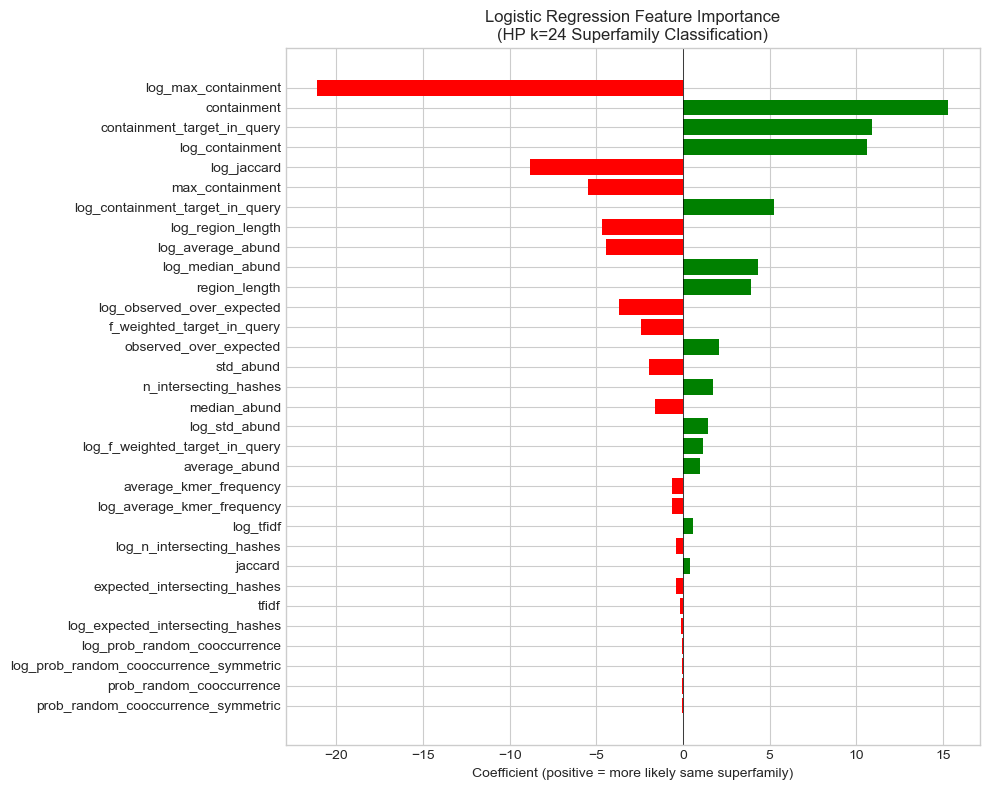


INTERPRETATION

Top features indicating SAME superfamily:
  - containment: 15.3158
  - containment_target_in_query: 10.8925
  - log_containment: 10.6342

Top features indicating DIFFERENT superfamily:
  - log_max_containment: -21.1029
  - log_jaccard: -8.8121
  - max_containment: -5.4999


In [7]:
# Feature Importance Analysis
print("="*70)
print("FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("="*70)

# Get coefficients
coef_df = pl.DataFrame({
    'feature': available_features,
    'coefficient': lr.coef_[0],
    'abs_coefficient': np.abs(lr.coef_[0])
}).sort('abs_coefficient', descending=True)

print("\nFeatures ranked by importance (absolute coefficient):")
print("-"*60)
for row in coef_df.iter_rows(named=True):
    direction = "+" if row['coefficient'] > 0 else "-"
    bar = "█" * int(row['abs_coefficient'] * 10)
    print(f"{row['feature']:<40} {direction} {row['abs_coefficient']:.4f} {bar}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if c > 0 else 'red' for c in coef_df['coefficient'].to_list()]
ax.barh(coef_df['feature'].to_list()[::-1], coef_df['coefficient'].to_list()[::-1], color=colors[::-1])
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Coefficient (positive = more likely same superfamily)')
ax.set_title('Logistic Regression Feature Importance\n(HP k=24 Superfamily Classification)')
plt.tight_layout()
plt.savefig('hp_k24_feature_importance.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
top_positive = coef_df.filter(pl.col('coefficient') > 0).head(3)
top_negative = coef_df.filter(pl.col('coefficient') < 0).head(3)
print("\nTop features indicating SAME superfamily:")
for row in top_positive.iter_rows(named=True):
    print(f"  - {row['feature']}: {row['coefficient']:.4f}")
print("\nTop features indicating DIFFERENT superfamily:")
for row in top_negative.iter_rows(named=True):
    print(f"  - {row['feature']}: {row['coefficient']:.4f}")


In [9]:
# Optimize ML model for sensitivity-until-first-FP AUC
print("="*70)
print("OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE")
print("="*70)

# Apply ML model to full dataset
X_full = hp_ml.select(available_features).drop_nulls().to_numpy()
X_full = np.nan_to_num(X_full, nan=0.0, posinf=1e10, neginf=-1e10)
X_full_scaled = scaler.transform(X_full)
ml_scores = lr.predict_proba(X_full_scaled)[:, 1]

# Add ML scores to dataframe
hp_with_ml = hp_ml.drop_nulls(subset=available_features).with_columns([
    pl.lit(ml_scores).alias('ml_score')
])

# Sweep ML score thresholds - include fine-grained 0.9-0.99 range
thresholds = list(np.arange(0.1, 0.9, 0.1)) + list(np.arange(0.9, 0.99, 0.01)) + [0.99]

print("\nSweeping ML score thresholds:")
print(f"{'Threshold':>10} {'SFAM AUC':>10} {'n_queries':>10} {'vs TEA':>10}")
print("-" * 45)

ml_threshold_results = []
for th in thresholds:
    auc, n_q = compute_sfam_auc_from_predictions(hp_with_ml, 'ml_score', th)
    beats = auc > TARGET_AUC
    ml_threshold_results.append({'threshold': th, 'auc': auc, 'n_queries': n_q, 'beats_tea': beats})
    marker = '✓' if beats else ''
    print(f"{th:>10.2f} {auc:>10.4f} {n_q:>10} {marker:>10}")

# Find best threshold
results_df = pl.DataFrame(ml_threshold_results)
best_row = results_df.filter(pl.col('auc') == pl.col('auc').max())
best_th = best_row['threshold'][0]
best_auc = best_row['auc'][0]
best_n = best_row['n_queries'][0]

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"Best ML threshold: {best_th:.2f}")
print(f"Best SFAM AUC: {best_auc:.4f}")
print(f"Queries at best threshold: {best_n}")
print(f"TEA baseline AUC: {TARGET_AUC:.4f}")
print(f"Improvement: {(best_auc - TARGET_AUC)*100:.2f}% {'✓' if best_auc > TARGET_AUC else ''}")


OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE

Sweeping ML score thresholds:
 Threshold   SFAM AUC  n_queries     vs TEA
---------------------------------------------
      0.10     0.0520      13173           
      0.20     0.0589      12573           
      0.30     0.0649      12055           
      0.40     0.0724      11505           
      0.50     0.0806      10710           
      0.60     0.0963       9140           
      0.70     0.1252       7089           
      0.80     0.1750       4773           
      0.90     0.2591       2830           
      0.91     0.2717       2643           
      0.92     0.2864       2465           
      0.93     0.2994       2262           
      0.94     0.3160       2074           
      0.95     0.3397       1864           
      0.96     0.3606       1681           
      0.97     0.3840       1465           
      0.98     0.4162       1217           
      0.99     0.4854        893           

RESULTS
Best ML threshold: 0.99


In [10]:
# Apply ML model to full dataset (slow - only run once)
print("Applying ML model to full dataset...")
X_full = hp_ml.select(available_features).drop_nulls().to_numpy()
X_full = np.nan_to_num(X_full, nan=0.0, posinf=1e10, neginf=-1e10)
X_full_scaled = scaler.transform(X_full)
ml_scores = lr.predict_proba(X_full_scaled)[:, 1]

# Add ML scores to dataframe
hp_with_ml = hp_ml.drop_nulls(subset=available_features).with_columns([
    pl.lit(ml_scores).alias('ml_score')
])
print(f"Done. {len(hp_with_ml)} rows with ML scores.")
print(f"ML score range: {ml_scores.min():.4f} - {ml_scores.max():.4f}")


Applying ML model to full dataset...
Done. 223459 rows with ML scores.
ML score range: 0.0000 - 1.0000


In [16]:
# Threshold sweep (fast - can rerun with different thresholds)
print("="*70)
print("OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE")
print("="*70)

# Comprehensive threshold sweep
thresholds = (
    list(np.arange(0.99, 0.999, 0.001)) + # 0.99-0.998
    [0.999, 0.9999]  # ultra-high
)

print(f"\nTesting {len(thresholds)} thresholds...")
print(f"{'Threshold':>10} {'SFAM AUC':>10} {'n_queries':>10} {'vs TEA':>10}")
print("-" * 45)

ml_threshold_results = []
for th in thresholds:
    auc, n_q = compute_sfam_auc_from_predictions(hp_with_ml, 'ml_score', th)
    beats = auc > TARGET_AUC
    ml_threshold_results.append({'threshold': th, 'auc': auc, 'n_queries': n_q, 'beats_tea': beats})
    marker = '✓' if beats else ''
    # Only print if notable
    if beats or auc > 0.5:
        print(f"{th:>10.4f} {auc:>10.4f} {n_q:>10} {marker:>10}")

# Find best threshold
results_df = pl.DataFrame(ml_threshold_results)
best_row = results_df.filter(pl.col('auc') == pl.col('auc').max())
best_th = best_row['threshold'][0]
best_auc = best_row['auc'][0]
best_n = best_row['n_queries'][0]

# Also find all thresholds that beat TEA
beating_tea = results_df.filter(pl.col('beats_tea') == 1)

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"Best ML threshold: {best_th:.4f}")
print(f"Best SFAM AUC: {best_auc:.4f}")
print(f"Queries at best threshold: {best_n}")
print(f"TEA baseline AUC: {TARGET_AUC:.4f}")

if len(beating_tea) > 0:
    print(f"\n✓ {len(beating_tea)} thresholds beat TEA!")
    print(beating_tea.sort('auc', descending=True))
else:
    print(f"\n✗ No threshold beats TEA (best: {best_auc:.4f} vs {TARGET_AUC:.4f})")
    print(f"  Gap: {(TARGET_AUC - best_auc)*100:.2f}%")
    print("\nTop 10 closest:")
    print(results_df.sort('auc', descending=True).head(10))


OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE

Testing 12 thresholds...
 Threshold   SFAM AUC  n_queries     vs TEA
---------------------------------------------
    0.9920     0.5055        814           
    0.9930     0.5223        761           
    0.9940     0.5406        715           
    0.9950     0.5546        668           
    0.9960     0.5752        618           
    0.9970     0.5963        571          ✓
    0.9980     0.6172        516          ✓
    0.9990     0.6727        411          ✓
    0.9990     0.6727        411          ✓
    0.9999     0.7651        232          ✓

RESULTS
Best ML threshold: 0.9999
Best SFAM AUC: 0.7651
Queries at best threshold: 232
TEA baseline AUC: 0.5800

✓ 5 thresholds beat TEA!
shape: (5, 4)
┌───────────┬──────────┬───────────┬───────────┐
│ threshold ┆ auc      ┆ n_queries ┆ beats_tea │
│ ---       ┆ ---      ┆ ---       ┆ ---       │
│ f64       ┆ f64      ┆ i64       ┆ f64       │
╞═══════════╪══════════╪═══════════╪═════

In [18]:
# Threshold sweep (fast - can rerun with different thresholds)
print("="*70)
print("OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE")
print("="*70)

# Comprehensive threshold sweep - use sorted unique values
thresholds = sorted(set(
    [round(x, 4) for x in np.arange(0.01, 0.1, 0.01)] +
    [round(x, 4) for x in np.arange(0.1, 0.9, 0.05)] +
    [round(x, 4) for x in np.arange(0.9, 0.99, 0.01)] +
    [round(x, 4) for x in np.arange(0.99, 0.999, 0.001)] +
    [0.999, 0.9995, 0.9999]
))

print(f"\nTesting {len(thresholds)} thresholds...")
print(f"{'Threshold':>10} {'SFAM AUC':>10} {'n_queries':>10} {'vs TEA':>10}")
print("-" * 45)

ml_threshold_results = []
for th in thresholds:
    auc, n_q = compute_sfam_auc_from_predictions(hp_with_ml, 'ml_score', th)
    beats = auc > TARGET_AUC
    ml_threshold_results.append({'threshold': th, 'auc': auc, 'n_queries': n_q, 'beats_tea': beats})
    marker = '✓' if beats else ''
    # Only print if notable
    if beats or auc > 0.5:
        print(f"{th:>10.4f} {auc:>10.4f} {n_q:>10} {marker:>10}")

# Find best threshold
results_df = pl.DataFrame(ml_threshold_results)
best_row = results_df.filter(pl.col('auc') == pl.col('auc').max())
best_th = best_row['threshold'][0]
best_auc = best_row['auc'][0]
best_n = best_row['n_queries'][0]

# Also find all thresholds that beat TEA
beating_tea = results_df.filter(pl.col('beats_tea') == 1)

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"Best ML threshold: {best_th:.4f}")
print(f"Best SFAM AUC: {best_auc:.4f}")
print(f"Queries at best threshold: {best_n}")
print(f"TEA baseline AUC: {TARGET_AUC:.4f}")

if len(beating_tea) > 0:
    print(f"\n✓ {len(beating_tea)} thresholds beat TEA!")
    print(beating_tea.sort('auc', descending=True))
else:
    print(f"\n✗ No threshold beats TEA (best: {best_auc:.4f} vs {TARGET_AUC:.4f})")
    print(f"  Gap: {(TARGET_AUC - best_auc)*100:.2f}%")
    print("\nTop 10 closest:")
    print(results_df.sort('auc', descending=True).head(10))


OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE

Testing 46 thresholds...
 Threshold   SFAM AUC  n_queries     vs TEA
---------------------------------------------
    0.9920     0.5055        814           
    0.9930     0.5223        761           
    0.9940     0.5406        715           
    0.9950     0.5546        668           
    0.9960     0.5752        618           
    0.9970     0.5963        571          ✓
    0.9980     0.6172        516          ✓
    0.9990     0.6727        411          ✓
    0.9995     0.7238        353          ✓
    0.9999     0.7651        232          ✓

RESULTS
Best ML threshold: 0.9999
Best SFAM AUC: 0.7651
Queries at best threshold: 232
TEA baseline AUC: 0.5800

✓ 5 thresholds beat TEA!
shape: (5, 4)
┌───────────┬──────────┬───────────┬───────────┐
│ threshold ┆ auc      ┆ n_queries ┆ beats_tea │
│ ---       ┆ ---      ┆ ---       ┆ ---       │
│ f64       ┆ f64      ┆ i64       ┆ f64       │
╞═══════════╪══════════╪═══════════╪═════

In [19]:
# Threshold sweep (fast - can rerun with different thresholds)
print("="*70)
print("OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE")
print("="*70)

# Comprehensive threshold sweep - use sorted unique values
thresholds = sorted(set(
    [round(x, 4) for x in np.arange(0.01, 0.1, 0.01)] +
    [round(x, 4) for x in np.arange(0.1, 0.9, 0.05)] +
    [round(x, 4) for x in np.arange(0.9, 0.99, 0.01)] +
    [round(x, 4) for x in np.arange(0.99, 0.999, 0.001)] +
    [0.999, 0.9995, 0.9999]
))

print(f"\nTesting {len(thresholds)} thresholds...")
print(f"{'Threshold':>10} {'SFAM AUC':>10} {'n_queries':>10} {'vs TEA':>10}")
print("-" * 45)

ml_threshold_results = []
for th in thresholds:
    auc, n_q = compute_sfam_auc_from_predictions(hp_with_ml, 'ml_score', th)
    beats = auc > TARGET_AUC
    ml_threshold_results.append({'threshold': th, 'auc': auc, 'n_queries': n_q, 'beats_tea': beats})
    marker = '✓' if beats else ''
    # Only print if notable
    if beats or auc > 0.5:
        print(f"{th:>10.4f} {auc:>10.4f} {n_q:>10} {marker:>10}")

# Find best threshold
results_df = pl.DataFrame(ml_threshold_results)
best_row = results_df.filter(pl.col('auc') == pl.col('auc').max())
best_th = best_row['threshold'][0]
best_auc = best_row['auc'][0]
best_n = best_row['n_queries'][0]

# Also find all thresholds that beat TEA
beating_tea = results_df.filter(pl.col('beats_tea') == True)

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"Best ML threshold: {best_th:.4f}")
print(f"Best SFAM AUC: {best_auc:.4f}")
print(f"Queries at best threshold: {best_n}")
print(f"TEA baseline AUC: {TARGET_AUC:.4f}")

if len(beating_tea) > 0:
    print(f"\n✓ {len(beating_tea)} thresholds beat TEA!")
    print(beating_tea.sort('auc', descending=True))
else:
    print(f"\n✗ No threshold beats TEA (best: {best_auc:.4f} vs {TARGET_AUC:.4f})")
    print(f"  Gap: {(TARGET_AUC - best_auc)*100:.2f}%")
    print("\nTop 10 closest:")
    print(results_df.sort('auc', descending=True).head(10))


OPTIMIZING FOR SENSITIVITY UNTIL FIRST FALSE POSITIVE

Testing 46 thresholds...
 Threshold   SFAM AUC  n_queries     vs TEA
---------------------------------------------
    0.9920     0.5055        814           
    0.9930     0.5223        761           
    0.9940     0.5406        715           
    0.9950     0.5546        668           
    0.9960     0.5752        618           
    0.9970     0.5963        571          ✓
    0.9980     0.6172        516          ✓
    0.9990     0.6727        411          ✓
    0.9995     0.7238        353          ✓
    0.9999     0.7651        232          ✓

RESULTS
Best ML threshold: 0.9999
Best SFAM AUC: 0.7651
Queries at best threshold: 232
TEA baseline AUC: 0.5800

✓ 5 thresholds beat TEA!
shape: (5, 4)
┌───────────┬──────────┬───────────┬───────────┐
│ threshold ┆ auc      ┆ n_queries ┆ beats_tea │
│ ---       ┆ ---      ┆ ---       ┆ ---       │
│ f64       ┆ f64      ┆ i64       ┆ f64       │
╞═══════════╪══════════╪═══════════╪═════

In [23]:
# Analyze feature values at ML thresholds that beat TEA
print("="*70)
print("FEATURE VALUES AT THRESHOLDS THAT BEAT TEA")
print("="*70)

# Key features to analyze
key_features = ['containment', 'jaccard', 'tfidf', 'n_intersecting_hashes', 
                'max_containment', 'average_abund', 'observed_over_expected']

# Analyze at a few key thresholds
for th in [0.997, 0.999, 0.9999]:
    filtered = hp_with_ml.filter(pl.col('ml_score') > th)
    print(f"\n{'='*70}")
    print(f"ML Score > {th} ({len(filtered)} rows)")
    print(f"{'='*70}")
    
    if len(filtered) > 0:
        # Get summary stats for key features
        for feat in key_features:
            if feat in filtered.columns:
                col = filtered[feat]
                print(f"\n{feat}:")
                print(f"  min:    {col.min():.4f}")
                print(f"  median: {col.median():.4f}")
                print(f"  mean:   {col.mean():.4f}")
                print(f"  max:    {col.max():.4f}")

# Show actual data at highest threshold
print("\n" + "="*70)
print("SAMPLE DATA AT ML SCORE > 0.9999")
print("="*70)
high_conf = hp_with_ml.filter(pl.col('ml_score') > 0.9999)
if len(high_conf) > 0:
    display_cols = ['ml_score', 'same_superfamily'] + key_features
    display_cols = [c for c in display_cols if c in high_conf.columns]
    print(high_conf.select(display_cols).head(20))


FEATURE VALUES AT THRESHOLDS THAT BEAT TEA

ML Score > 0.997 (912 rows)

containment:
  min:    0.0027
  median: 0.0692
  mean:   0.2730
  max:    1.0000

jaccard:
  min:    0.0027
  median: 0.0351
  mean:   0.0589
  max:    0.1695

tfidf:
  min:    17.8679
  median: 1303.2241
  mean:   1689.4208
  max:    7387.6853

n_intersecting_hashes:
  min:    1.0000
  median: 12.0000
  mean:   14.5943
  max:    69.0000

max_containment:
  min:    0.0091
  median: 0.0764
  mean:   0.3084
  max:    1.0000

average_abund:
  min:    1.0000
  median: 1.0000
  mean:   1.6339
  max:    3.8929

observed_over_expected:
  min:    1517.0000
  median: 6320.8333
  mean:   6255.2237
  max:    7585.0000

ML Score > 0.999 (703 rows)

containment:
  min:    0.0027
  median: 0.0822
  mean:   0.3376
  max:    1.0000

jaccard:
  min:    0.0027
  median: 0.0405
  mean:   0.0690
  max:    0.1695

tfidf:
  min:    17.8679
  median: 1154.2841
  mean:   1514.7385
  max:    6720.2605

n_intersecting_hashes:
  min:    1.0

Plotting distributions for 292 rows with ML score > 0.9999


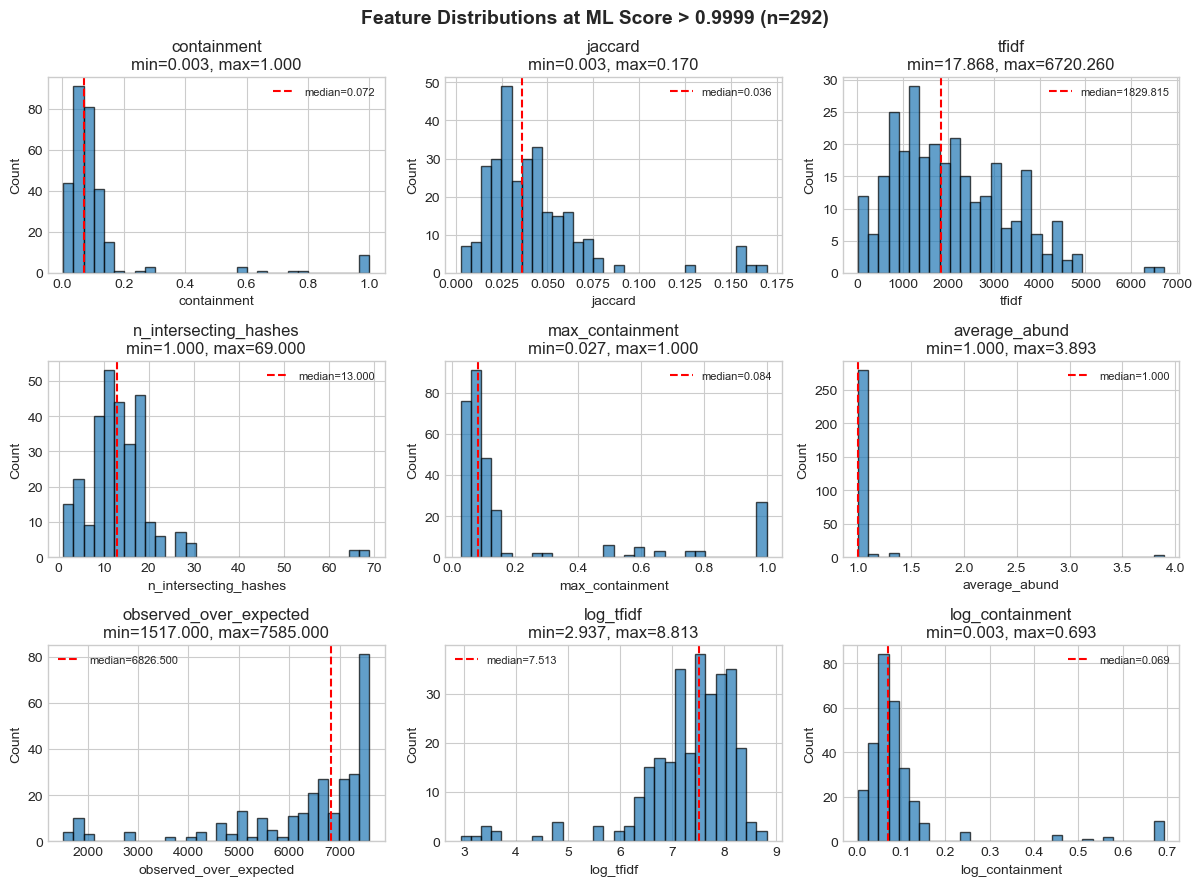

In [24]:
# Plot feature distributions at ML Score > 0.9999
high_conf = hp_with_ml.filter(pl.col('ml_score') > 0.9999)
print(f"Plotting distributions for {len(high_conf)} rows with ML score > 0.9999")

key_features = ['containment', 'jaccard', 'tfidf', 'n_intersecting_hashes', 
                'max_containment', 'average_abund', 'observed_over_expected',
                'log_tfidf', 'log_containment']
key_features = [f for f in key_features if f in high_conf.columns]

n_features = len(key_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    data = high_conf[feat].to_numpy()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.set_title(f'{feat}\nmin={data.min():.3f}, max={data.max():.3f}')
    ax.axvline(np.median(data), color='red', linestyle='--', label=f'median={np.median(data):.3f}')
    ax.legend(fontsize=8)

# Hide unused subplots
for i in range(len(key_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Feature Distributions at ML Score > 0.9999 (n={len(high_conf)})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_high_conf_feature_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()


ML Score > 0.9999: 292 total
  True Positives (same superfamily): 225 (77.1%)
  False Positives (diff superfamily): 67 (22.9%)


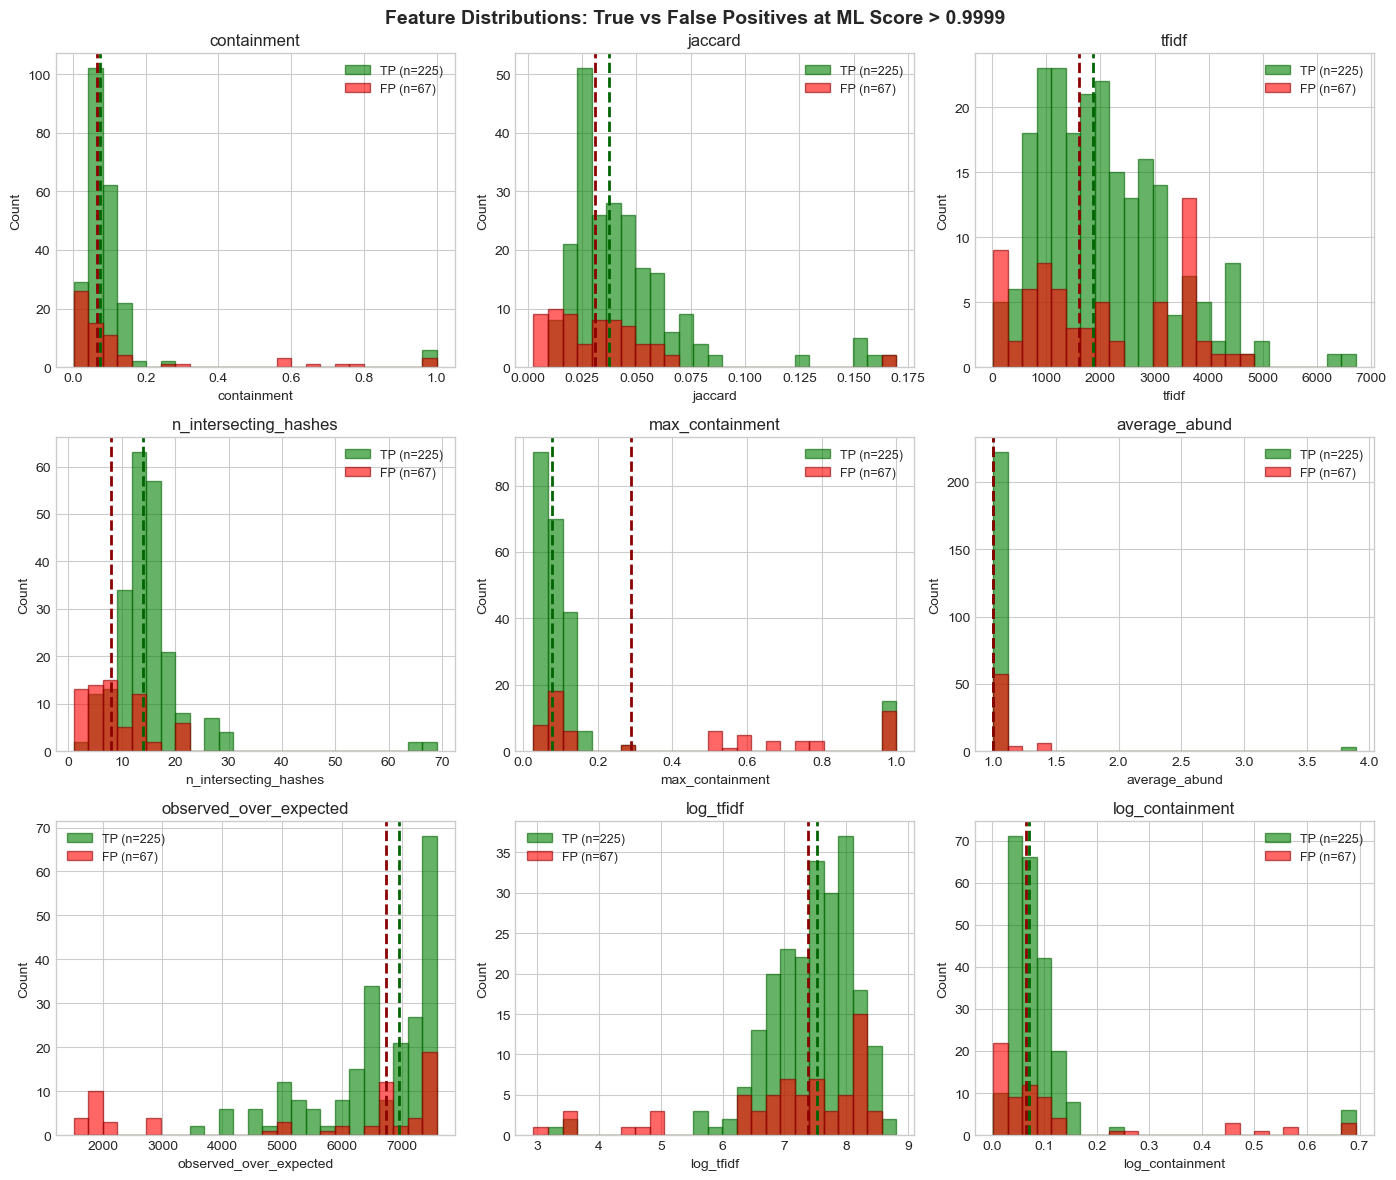


FEATURE COMPARISON: True Positives vs False Positives
Feature                      TP median    FP median   Difference
-----------------------------------------------------------------
containment                     0.0738       0.0677       0.0061
jaccard                         0.0374       0.0310       0.0064
tfidf                        1870.8625    1610.7205     260.1420
n_intersecting_hashes          14.0000       8.0000       6.0000
max_containment                 0.0763       0.2895      -0.2131
average_abund                   1.0000       1.0000       0.0000
observed_over_expected       6952.9167    6742.2222     210.6944
log_tfidf                       7.5347       7.3851       0.1496
log_containment                 0.0712       0.0655       0.0057


In [25]:
# Plot feature distributions by True Positive vs False Positive at ML Score > 0.9999
high_conf = hp_with_ml.filter(pl.col('ml_score') > 0.9999)

# Split by same_superfamily (TP = same superfamily, FP = different superfamily)
tp = high_conf.filter(pl.col('same_superfamily') == 1)  # True Positives
fp = high_conf.filter(pl.col('same_superfamily') == 0)  # False Positives

print(f"ML Score > 0.9999: {len(high_conf)} total")
print(f"  True Positives (same superfamily): {len(tp)} ({len(tp)/len(high_conf)*100:.1f}%)")
print(f"  False Positives (diff superfamily): {len(fp)} ({len(fp)/len(high_conf)*100:.1f}%)")

key_features = ['containment', 'jaccard', 'tfidf', 'n_intersecting_hashes', 
                'max_containment', 'average_abund', 'observed_over_expected',
                'log_tfidf', 'log_containment']
key_features = [f for f in key_features if f in high_conf.columns]

n_features = len(key_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    
    tp_data = tp[feat].to_numpy()
    fp_data = fp[feat].to_numpy()
    
    # Get common bin edges
    all_data = high_conf[feat].to_numpy()
    bins = np.histogram_bin_edges(all_data, bins=25)
    
    ax.hist(tp_data, bins=bins, alpha=0.6, label=f'TP (n={len(tp_data)})', color='green', edgecolor='darkgreen')
    ax.hist(fp_data, bins=bins, alpha=0.6, label=f'FP (n={len(fp_data)})', color='red', edgecolor='darkred')
    
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    
    # Add median lines
    if len(tp_data) > 0:
        ax.axvline(np.median(tp_data), color='darkgreen', linestyle='--', linewidth=2)
    if len(fp_data) > 0:
        ax.axvline(np.median(fp_data), color='darkred', linestyle='--', linewidth=2)
    
    ax.legend(fontsize=9)
    ax.set_title(feat)

# Hide unused subplots
for i in range(len(key_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Feature Distributions: True vs False Positives at ML Score > 0.9999', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_high_conf_tp_fp_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Print summary stats comparison
print("\n" + "="*70)
print("FEATURE COMPARISON: True Positives vs False Positives")
print("="*70)
print(f"{'Feature':<25} {'TP median':>12} {'FP median':>12} {'Difference':>12}")
print("-"*65)
for feat in key_features:
    tp_med = tp[feat].median() if len(tp) > 0 else 0
    fp_med = fp[feat].median() if len(fp) > 0 else 0
    diff = tp_med - fp_med
    print(f"{feat:<25} {tp_med:>12.4f} {fp_med:>12.4f} {diff:>12.4f}")
